# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

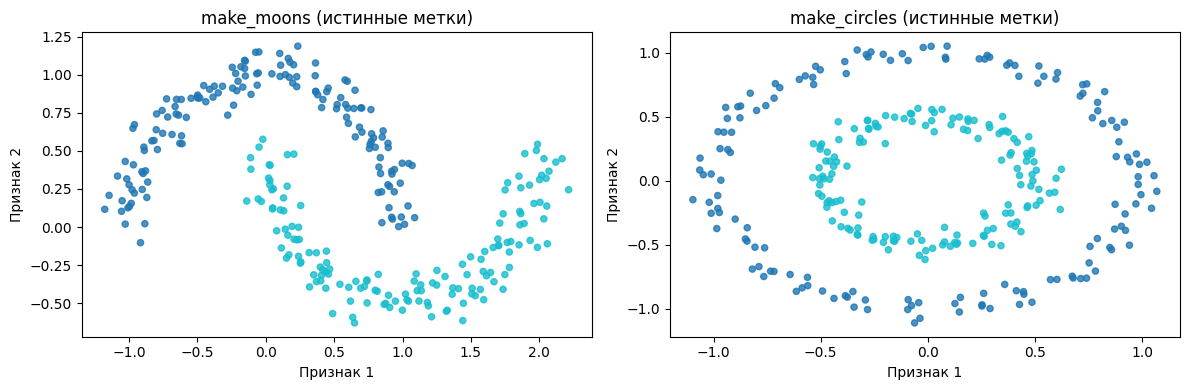

In [3]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

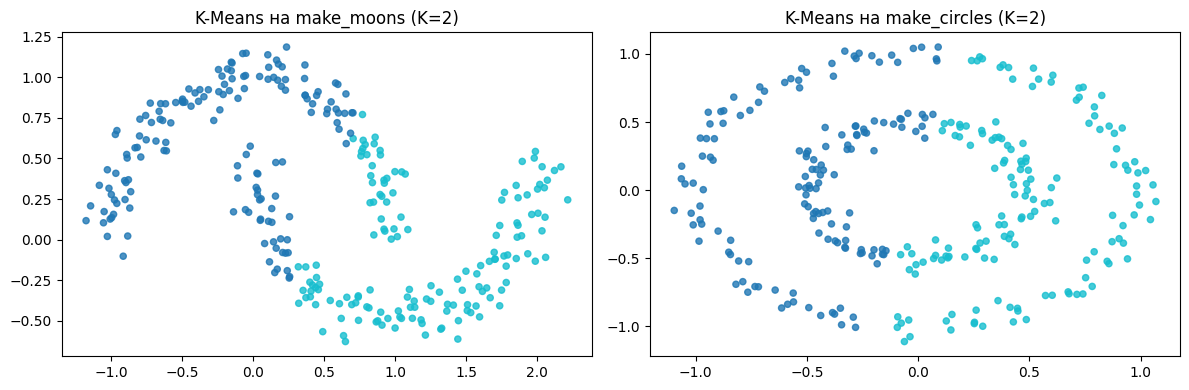

In [4]:
# Применим K-Means к этим датасетам
# YOUR CODE HERE
# 1. Создайте KMeans с n_clusters=2, random_state=RANDOM_STATE
# 2. Обучите на X_moons и X_circles
# 3. Получите метки кластеров

kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)  # замените None
kmeans_moons.fit(X_moons)
labels_km_moons = kmeans_moons.labels_

kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)
kmeans_circles.fit(X_circles)
labels_km_circles = kmeans_circles.labels_

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?
Потому что KMeans минимизирует *сумму квадратов расстояний* от каждой точки до центра кластера, а для колец и и дуг центры, которые должны быть, оказываются в пустоте. на выпуклых множествах такого бы не было. Так что, да, связано.

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

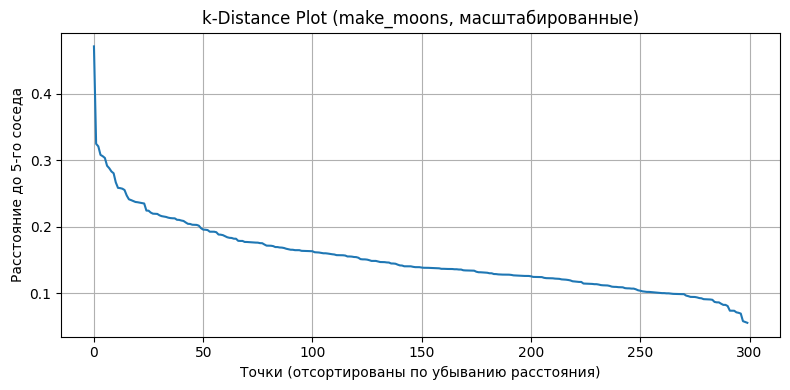

Найдите 'локоть' на графике и запишите подходящее значение eps:


In [5]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

# YOUR CODE HERE
# 1. Создайте NearestNeighbors(n_neighbors=k) и обучите на X_moons_scaled
# 2. Вызовите .kneighbors() для получения матрицы расстояний
# 3. Возьмите расстояние до k-го соседа (последний столбец distances)
# 4. Отсортируйте по убыванию

nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_moons_scaled)

dists, inds = nn.kneighbors(X_moons_scaled)
k_dist = dists[:, -1]
k_distances_moons = np.sort(k_dist)[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?
- локоть находится примерно на 0.25 по y. возьму eps=0.25

- точки, у которых расстояние до k-го соседа меньше eps, считаются плотными (внутри кластеров). Точки, у которых это расстояние больше eps, — разреженные (шум или граница)

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

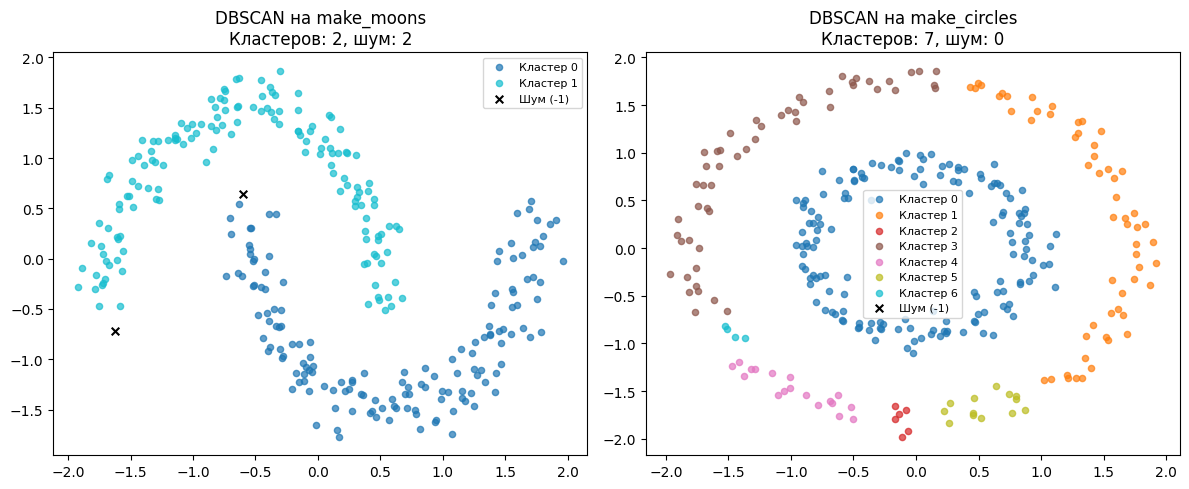

In [6]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# YOUR CODE HERE
# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера

db_moons = DBSCAN(eps=0.25, min_samples=5)   # замените
db_moons.fit_predict(X_moons_scaled)
labels_db_moons = db_moons.labels_

db_circles = DBSCAN(eps=0.25, min_samples=5)
db_circles.fit_predict(X_circles_scaled)
labels_db_circles = db_circles.labels_

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

для make_moons почти идеально подошли параметры(есть небольшой шум), для make_circles попробую увеличить и eps, и min_samples

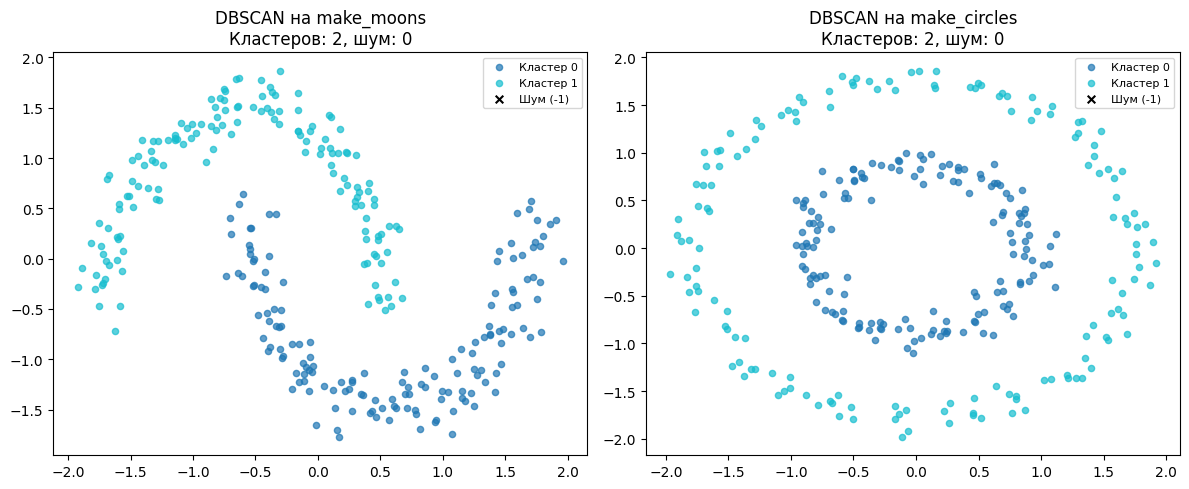

In [7]:
db_moons_2 = DBSCAN(eps=0.3, min_samples=5)
labels_db_moons_2 = db_moons_2.fit_predict(X_moons_scaled)

db_circles_2 = DBSCAN(eps=0.45, min_samples=10)
labels_db_circles_2 = db_circles_2.fit_predict(X_circles_scaled)

# Визуализация с теми же функциями
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons_2, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles_2, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [8]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1

k_means_m = KMeans(n_clusters=2, random_state=RANDOM_STATE)  # замените
kmeans_labels = k_means_m.fit_predict(X_moons_scaled)
score_kmeans = silhouette_score(X_moons_scaled, kmeans_labels) 
db_labels = labels_db_moons_2

mask = db_labels != -1
X_filtered = X_moons_scaled[mask]
labels_filtered = db_labels[mask]

score_dbscan = silhouette_score(X_filtered, labels_filtered)

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.380


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?
Силуэт получился лучше у KMeans, такое могло произойти, учитывая, как он работает. Силуэт не является надёжной оценкой качества на нелинейных данных

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

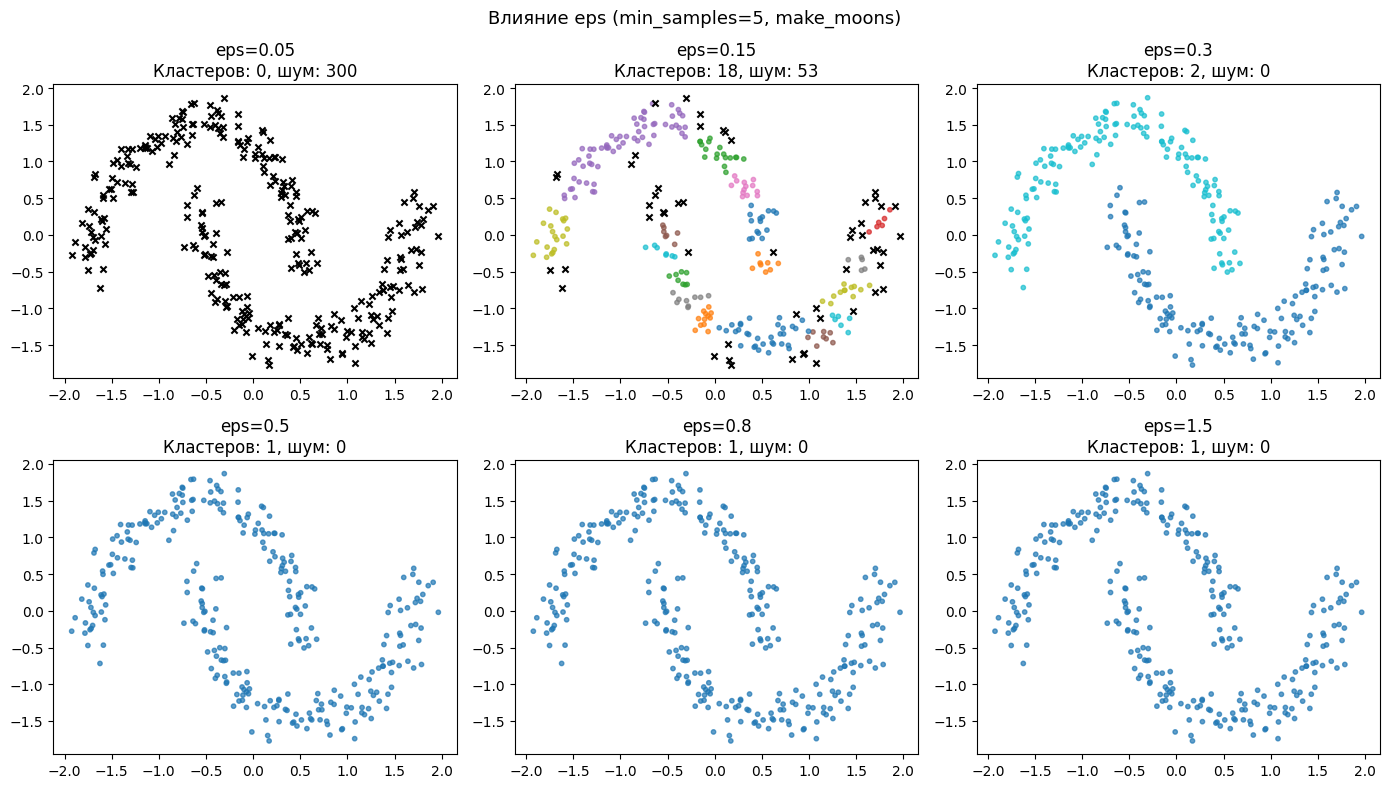

In [9]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    # YOUR CODE HERE
    # 1. Запустите DBSCAN(eps=eps_val, min_samples=5) на X_moons_scaled
    db = DBSCAN(eps=eps_val, min_samples=5)
    # 2. Получите метки
    labels_i = db.fit_predict(X_moons_scaled)
    # 3. Посчитайте число кластеров и шумовых точек
    n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
    n_noise = (labels_i == -1).sum()
    # 4. Отобразите scatter plot с цветами по меткам
    #    Шумовые точки (label == -1) рисуйте чёрными крестиками
    mask = labels_i != -1
    axes[i].scatter(X_moons_scaled[mask, 0], X_moons_scaled[mask, 1],
                    c=labels_i[mask], cmap='tab10', s=10, alpha=0.7)
    # шум
    axes[i].scatter(X_moons_scaled[~mask, 0], X_moons_scaled[~mask, 1],
                    c='black', marker='x', s=20)
    axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?
при eps = 0.3. при слишком малом eps у каждой точки слишком мало других точек попадает в её окрестность. алгоритм смотрит, если таких точек ≥ min_samples, то точка считается корневой и тогда может расширять свой кластер, но может взять не весь, при малом eps. или наоборот слишком много точек при большом eps

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [10]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

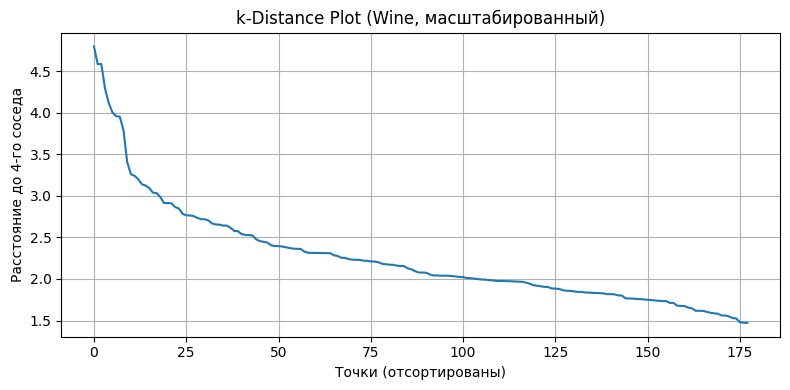

In [11]:
# YOUR CODE HERE
# 1. Масштабируйте X_wine с помощью StandardScaler
# 2. Постройте k-distance plot (k=4)
# 3. Визуально определите «локоть» и запишите подходящее eps
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)  # замените

k_wine = 4
nn_wine = NearestNeighbors(n_neighbors=k_wine)
nn_wine.fit(X_wine_scaled)
distances, indices = nn_wine.kneighbors(X_wine_scaled)
k_dist = distances[:, -1]
k_dist_wine = np.sort(k_dist)[::-1]

plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# YOUR CODE HERE
# 1. Запустите DBSCAN на X_wine_scaled с выбранным eps и min_samples=4
# 2. Выведите: число кластеров, число шумовых точек, долю шума
# 3. Если кластеров > 1, вычислите силуэт (исключив шум)

eps_wine = 2.1   # ИЗМЕНИТЕ на основе k-distance plot
db_wine = DBSCAN(eps=eps_wine, min_samples=4)
labels_wine = db_wine.fit_predict(X_wine_scaled)  # замените

unique_labels = set(labels_wine)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

n_noise = list(labels_wine).count(-1)

noise_ratio = n_noise / len(labels_wine)

print("=== Результаты DBSCAN на Wine ===")
# ваш код для вывода статистики
print(f"Параметры: eps={eps_wine}, min_samples=4")
print(f"Количество кластеров: {n_clusters}")
print(f"Количество шумовых точек: {n_noise} ({noise_ratio:.2%})")

if n_clusters >= 2:
    mask = labels_wine != -1
    X_filtered = X_wine_scaled[mask]
    labels_filtered = labels_wine[mask]
    if len(set(labels_filtered)) >= 2:
        score = silhouette_score(X_filtered, labels_filtered)
        print(f"Коэффициент силуэта (без шума): {score:.3f}")
    else:
        print("Недостаточно кластеров")
else:
    print("меньше 2 кластеров")

=== Результаты DBSCAN на Wine ===
Параметры: eps=2.1, min_samples=4
Количество кластеров: 3
Количество шумовых точек: 57 (32.02%)
Коэффициент силуэта (без шума): 0.211


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [13]:
# YOUR CODE HERE
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего?

noise_mask_wine = labels_wine == -1   # маска для шумовых точек
X_wine_noise = X_wine[noise_mask_wine]      # признаки шумовых точек

mean_all = df_wine.mean()
mean_noise = pd.DataFrame(X_wine_noise, columns=feature_names).mean()

comparison = pd.DataFrame({
    'Признак': feature_names,
    'Среднее (все)': mean_all.values,
    'Среднее (шум)': mean_noise.values,
    'Разница': mean_noise.values - mean_all.values,
    'Относительная разница (%)': (mean_noise.values - mean_all.values) / mean_all.values * 100
})
comparison = comparison.sort_values('Относительная разница (%)', key=abs, ascending=False)

print("=== Средние значения признаков ===")
print(comparison.to_string(index=False))
# ваш код

top_diff = comparison.iloc[0:3]
for _, row in top_diff.iterrows():
    print(f"{row['Признак']}: среднее у шума {row['Среднее (шум)']:.2f} vs общее {row['Среднее (все)']:.2f} (отличие {row['Относительная разница (%)']:.1f}%)")

=== Средние значения признаков ===
                     Признак  Среднее (все)  Среднее (шум)     Разница  Относительная разница (%)
                     proline     746.893258     645.350877 -101.542381                 -13.595300
             color_intensity       5.058090       4.447544   -0.610546                 -12.070684
                  malic_acid       2.336348       2.545614    0.209266                   8.956957
             proanthocyanins       1.590899       1.713860    0.122961                   7.729012
           alcalinity_of_ash      19.494944      20.089474    0.594530                   3.049662
        nonflavanoid_phenols       0.361854       0.372456    0.010602                   2.929969
od280/od315_of_diluted_wines       2.611685       2.540000   -0.071685                  -2.744794
                     alcohol      13.000618      12.739474   -0.261144                  -2.008707
               total_phenols       2.295112       2.340702    0.045589             

**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?
скорее всего, это реальные аномалии. лучше их не удалять, могут указать на какие-то подгруппы или их нужно ещё анализировать.

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

Сравнение силуэта на Wine:
K-Means (k=3):   0.285
DBSCAN (без шума): 0.211


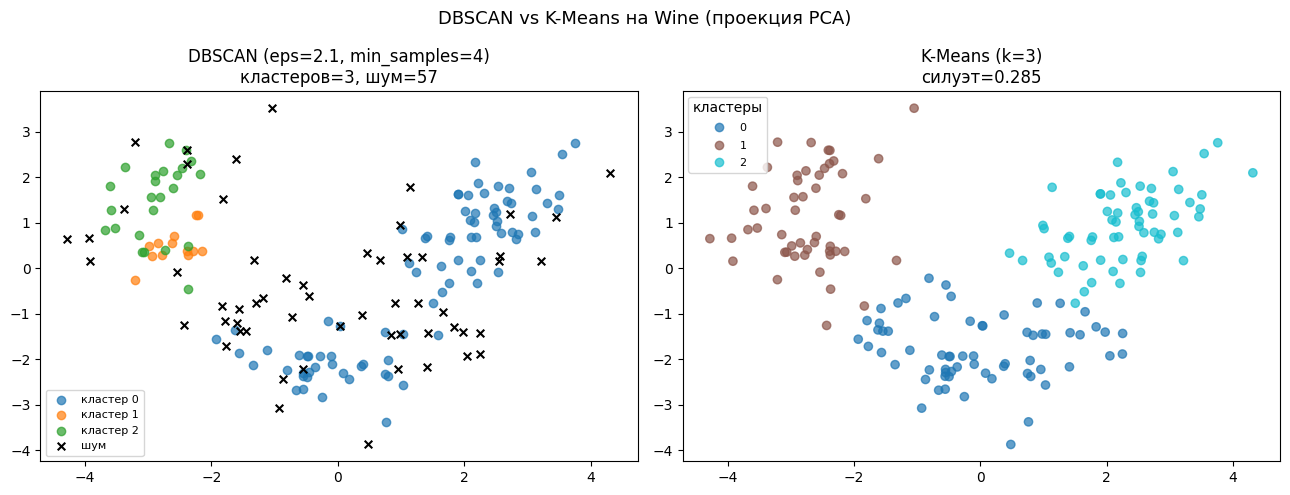

In [14]:
# YOUR CODE HERE
# 1. Обучите KMeans с числом кластеров = числу кластеров DBSCAN
#    (или с n_clusters=3, так как истинных классов 3)
# 2. Вычислите силуэт для K-Means
# 3. Сравните силуэт DBSCAN и K-Means
# 4. Визуализируйте результаты обоих методов в 2D (первые два признака
#    после масштабирования или используйте PCA до 2 компонент)

# Подсказка для PCA:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

# DBSCAN
# ваш код
db_wine_model = db_wine
db_silhouette = score

# K-Means
# ваш код
kmeans_wine_model = KMeans(n_clusters=3, random_state=RANDOM_STATE)
kmeans_wine_labels = kmeans_wine_model.fit_predict(X_wine_scaled)
kmeans_silhouette = silhouette_score(X_wine_scaled, kmeans_wine_labels)

print("Сравнение силуэта на Wine:")
print(f"K-Means (k=3):   {kmeans_silhouette:.3f}")
print(f"DBSCAN (без шума): {db_silhouette:.3f}") 

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DBSCAN: цвет по кластерам, шум — крестики
ax = axes[0]
for label in set(labels_wine):
    if label == -1:
        ax.scatter(X_wine_2d[labels_wine == -1, 0], X_wine_2d[labels_wine == -1, 1],
                   c='black', marker='x', s=30, label='шум')
    else:
        mask = labels_wine == label
        ax.scatter(X_wine_2d[mask, 0], X_wine_2d[mask, 1],
                   label=f'кластер {label}', alpha=0.7)
ax.set_title(f"DBSCAN (eps=2.1, min_samples=4)\nкластеров={len(set(labels_wine))-1}, шум={sum(labels_wine==-1)}")
ax.legend(fontsize=8)

# K-Means: все точки цветные, шума нет
ax = axes[1]
scatter = ax.scatter(X_wine_2d[:, 0], X_wine_2d[:, 1],
                     c=kmeans_wine_labels, cmap='tab10', alpha=0.7)
ax.set_title(f"K-Means (k=3)\nсилуэт={kmeans_silhouette:.3f}")
ax.legend(*scatter.legend_elements(), title="кластеры", fontsize=8)

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> Ваш ответ здесь.

Когда кластеры произвольной формы, датасет имеет шум и выбросы, нам неизвестно количество кластеров, например make_moons и make_circles DBSCAN правильно выделил 2 кластера, а K-Means — нет, несмотря на более высокий силуэт у K-Means

**2. Когда K-Means предпочтительнее?**

> Ваш ответ здесь.

K-Means предпочтительнее, когда:

- кластеры сферические, выпуклые и примерно одинакового размера (например, группы точек вокруг центров)

- данные чистые, без значительного шума

- требуется высокая производительность на больших данных – K-Means работает быстрее DBSCAN

- заранее известно число кластеров (например, из предметной области)

**3. Почему масштабирование обязательно для DBSCAN?**

> Ваш ответ здесь.

DBSCAN основан на евклидовом расстоянии, нам необходимо подобрать единый eps, поэтому необходимо, чтобы не было доминирования со стороны крупномасштабных признаков.

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Ваш ответ здесь.

если посмотреть результаты анализа признаков шумовых точек: 

=== Средние значения признаков ===

                     Признак  Среднее (все)  Среднее (шум)     Разница  Относительная разница (%)

                     proline     746.893258     645.350877 -101.542381                 -13.595300

             color_intensity       5.058090       4.447544   -0.610546                 -12.070684

                  malic_acid       2.336348       2.545614    0.209266                   8.956957

видно, что эти отклонения не являются ошибками измерения, а скорее указывают на редкие сорта вин, переходные образцы или точки на границе кластеров.

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Ваш ответ здесь.

я считаю, что некорректно т.к.:

1. DBSCAN выкидывает шумовые точки (-1) из расчёта силуэта, тогда как K-Means использует все точки. Если шум неоднороден, сравнение становится смещённым. то есть используется разное количество

2. силуэт измеряет среднее расстояние до своего и до соседнего кластера, поэтому подвержен давать хорошие показатели для сферических, компактных кластеров. поэтому DBSCAN может проигрывать